In [1]:
import os
import glob
import random
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import time
device = torch.device('cpu')
torch.manual_seed(0)
random.seed(0)
EXTENSIONES_VALIDAS = [".pgm", ".png", ".jpg", ".jpeg", ".bmp"]

In [2]:

DATASET_PATH = Path("../dataset")

CLEAN_DIR = DATASET_PATH / "ORL_Limpio"
DEGRADACION_DIR = DATASET_PATH / "Degradacion"

SCALE = 2  # 2 o 4 -> selecciona ORL_escala2 u ORL_escala4
IMG_SIZE = (112, 92)  # (alto, ancho)

DEGRADED_DIR = DEGRADACION_DIR / f"ORL_escala{SCALE}"

In [3]:
class LiteDenseBlock(nn.Module):
    def __init__(self, num_channel=32, growth_channel=8):
        super().__init__()
        self.conv1 = nn.Conv2d(num_channel, growth_channel, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_channel + growth_channel * 1, growth_channel, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_channel + growth_channel * 2, growth_channel, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_channel + growth_channel * 3, num_channel, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.conv4(torch.cat((x, x1, x2, x3), 1))
        return x + x4 * 0.2


class LiteRestoreNet(nn.Module):
    def __init__(self, num_channel=32, growth_channel=8, num_blocks=6, in_channels=1):
        super().__init__()
        self.conv_first = nn.Conv2d(in_channels, num_channel, 3, 1, 1)
        self.body = nn.Sequential(*[LiteDenseBlock(num_channel, growth_channel) for _ in range(num_blocks)])
        self.conv_after_body = nn.Conv2d(num_channel, num_channel, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_channel, in_channels, 3, 1, 1)

    def forward(self, x):
        feat_first = self.conv_first(x)
        feat = self.conv_after_body(self.body(feat_first)) + feat_first
        residual = self.conv_last(feat)
        return x + residual


def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [4]:
def _buscar_por_stem(carpeta: Path, stem: str):
    for ext in EXTENSIONES_VALIDAS:
        candidato = carpeta / f"{stem}{ext}"
        if candidato.is_file():
            return candidato
    return None


def list_pairs(clean_split_dir: Path, degraded_split_dir: Path):
    pairs = []
    subject_dirs = sorted(d for d in clean_split_dir.glob("s*") if d.is_dir())
    for clean_subj_dir in subject_dirs:
        subject_name = clean_subj_dir.name
        degraded_subj_dir = degraded_split_dir / subject_name
        assert degraded_subj_dir.is_dir(), f"Falta carpeta degradada: {degraded_subj_dir}"
        clean_files = sorted(f for f in clean_subj_dir.glob("*.*") if f.suffix.lower() in EXTENSIONES_VALIDAS)
        for clean_path in clean_files:
            degraded_path = _buscar_por_stem(degraded_subj_dir, clean_path.stem)
            assert degraded_path is not None, f"Falta par degradado para: {clean_path.name} en {degraded_subj_dir}"
            pairs.append((degraded_path, clean_path))
    return pairs


class PairedGraySRDataset(Dataset):
    def __init__(self, pairs, img_size=(112, 92)):
        self.pairs = pairs
        self.h, self.w = img_size
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        hr = Image.open(hr_path).convert('L')
        lr = Image.open(lr_path).convert('L')
        target_size = (self.w, self.h)
        if hr.size != target_size:
            hr = hr.resize(target_size, Image.BICUBIC)
        if lr.size != target_size:
            lr = lr.resize(target_size, Image.BICUBIC)
        return self.to_tensor(lr), self.to_tensor(hr)


train_pairs = list_pairs(CLEAN_DIR / "Training", DEGRADED_DIR / "Training")
test_pairs = list_pairs(CLEAN_DIR / "Testing", DEGRADED_DIR / "Testing")

train_ds = PairedGraySRDataset(train_pairs, img_size=IMG_SIZE)
val_ds = PairedGraySRDataset(test_pairs, img_size=IMG_SIZE)

print(f"[Escala x{SCALE}] Training pairs: {len(train_ds)}  (esperado 360)")
print(f"[Escala x{SCALE}] Testing pairs:  {len(val_ds)}  (esperado 40)")

[Escala x2] Training pairs: 360  (esperado 360)
[Escala x2] Testing pairs:  40  (esperado 40)


In [5]:
BATCH_SIZE = 16
EPOCHS = 100
LR_INIT = 3e-4
STEP_SIZE = 30
GAMMA = 0.5
PRINT_EVERY = 10

CHECKPOINT_PATH = Path("../model_lite") / f"literestorenet_escala{SCALE}_best.pth"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = LiteRestoreNet(num_channel=32, growth_channel=8, num_blocks=6, in_channels=1).to(device)
print(f"Parámetros: {count_parameters(model):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
l1_loss = nn.L1Loss()


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for lr_img, hr_img in loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            if train:
                optimizer.zero_grad()
            pred = model(lr_img)
            loss = l1_loss(pred, hr_img)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * lr_img.size(0)
            n += lr_img.size(0)
    return total_loss / n


print("Iniciando entrenamiento...")
print(f"   Escala   : x{SCALE}")
print(f"   Épocas   : {EPOCHS}")
print(f"   Batch    : {BATCH_SIZE}")
print(f"   LR init  : {LR_INIT}")
print(f"   Scheduler: StepLR(step={STEP_SIZE}, γ={GAMMA})")
print("─" * 64)

best_val_loss = float('inf')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    scheduler.step()
    elapsed = time.time() - t_epoch

    guardado = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
            'scale': SCALE,
        }, CHECKPOINT_PATH)
        guardado = "  ✦ guardado"

    if epoch == 1 or epoch % PRINT_EVERY == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Época [{epoch:3d}/{EPOCHS}]  train: {train_loss:.6f}  val: {val_loss:.6f}  "
              f"lr: {current_lr:.2e}  t: {elapsed:.0f}s{guardado}")

total_elapsed = time.time() - t_start
print("─" * 64)
print(f" Entrenamiento completado en {total_elapsed:.1f} s")
print(f" Mejor val loss: {best_val_loss:.6f}  →  {CHECKPOINT_PATH.name}")

Parámetros: 158,801
Iniciando entrenamiento...
   Escala   : x2
   Épocas   : 100
   Batch    : 16
   LR init  : 0.0003
   Scheduler: StepLR(step=30, γ=0.5)
────────────────────────────────────────────────────────────────
Época [  1/100]  train: 0.100865  val: 0.067479  lr: 3.00e-04  t: 35s  ✦ guardado
Época [ 10/100]  train: 0.055818  val: 0.055828  lr: 3.00e-04  t: 32s
Época [ 20/100]  train: 0.051918  val: 0.049104  lr: 3.00e-04  t: 27s  ✦ guardado
Época [ 30/100]  train: 0.048630  val: 0.046960  lr: 1.50e-04  t: 27s
Época [ 40/100]  train: 0.047608  val: 0.045861  lr: 1.50e-04  t: 32s
Época [ 50/100]  train: 0.046458  val: 0.045440  lr: 1.50e-04  t: 31s
Época [ 60/100]  train: 0.045983  val: 0.044707  lr: 7.50e-05  t: 31s
Época [ 70/100]  train: 0.045626  val: 0.045035  lr: 7.50e-05  t: 31s
Época [ 80/100]  train: 0.045109  val: 0.045256  lr: 7.50e-05  t: 32s
Época [ 90/100]  train: 0.044839  val: 0.043697  lr: 3.75e-05  t: 31s
Época [100/100]  train: 0.044508  val: 0.043386  lr: 3

Pesos cargados desde época 100  (val_loss=0.043386)


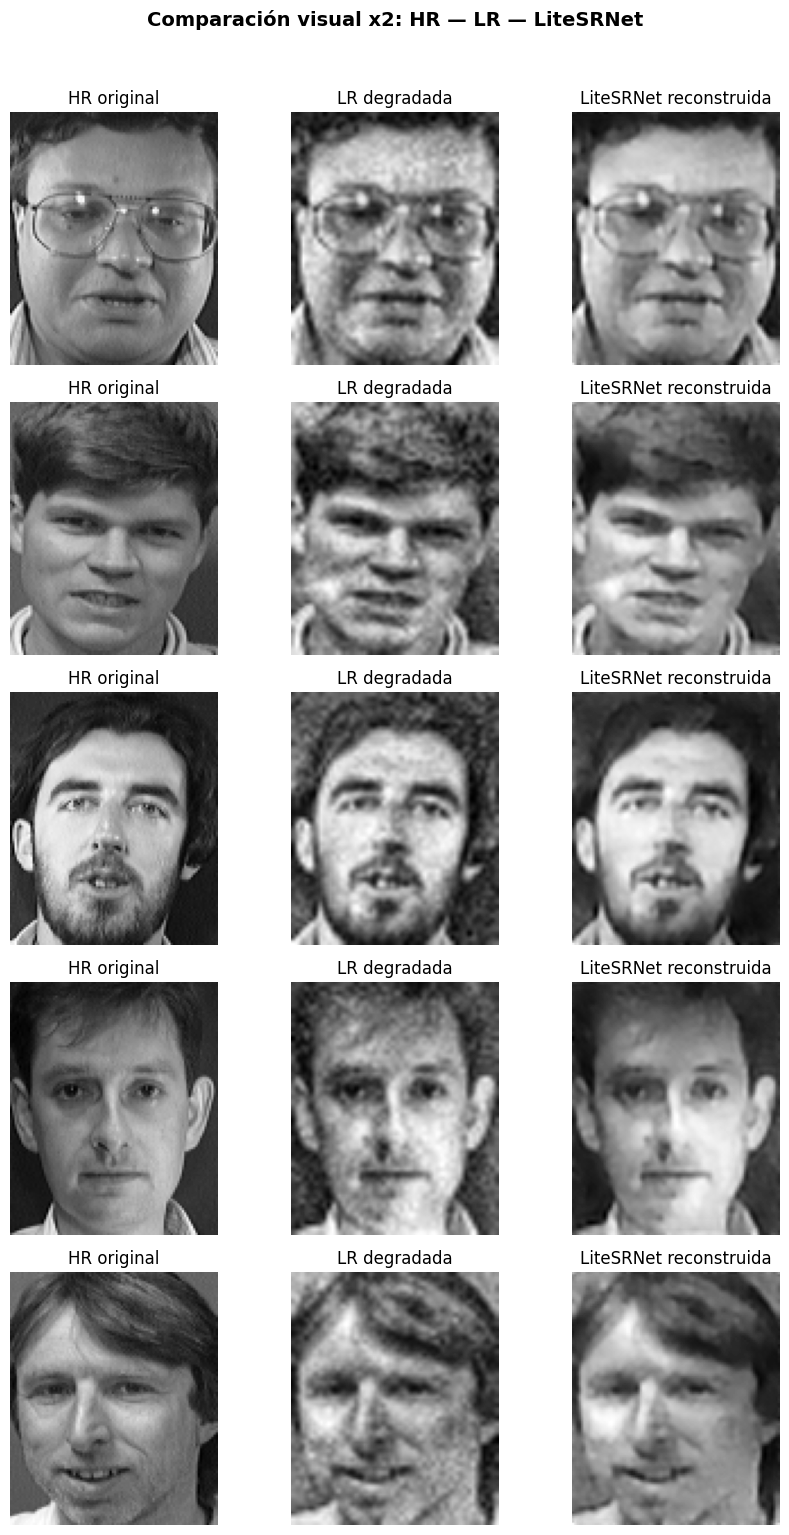

In [6]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Pesos cargados desde época {checkpoint['epoch']}  (val_loss={checkpoint['val_loss']:.6f})")


def tensor_to_np(t):
    return t.squeeze().detach().cpu().numpy()


def mostrar_comparacion(n_examples=5, cmap='gray'):
    fig, axes = plt.subplots(n_examples, 3, figsize=(9, 3 * n_examples))
    fig.suptitle(f"Comparación visual x{SCALE}: HR — LR — LiteSRNet", fontsize=14, fontweight='bold', y=1.02)
    indices = random.sample(range(len(val_ds)), n_examples)
    with torch.no_grad():
        for row, idx in enumerate(indices):
            lr_img, hr_img = val_ds[idx]
            pred = model(lr_img.unsqueeze(0).to(device))
            axes[row, 0].imshow(tensor_to_np(hr_img), cmap=cmap)
            axes[row, 0].set_title("HR original")
            axes[row, 1].imshow(tensor_to_np(lr_img), cmap=cmap, interpolation='bilinear')
            axes[row, 1].set_title("LR degradada")
            axes[row, 2].imshow(tensor_to_np(pred), cmap=cmap)
            axes[row, 2].set_title("LiteSRNet reconstruida")
            for ax in axes[row]:
                ax.axis('off')
    plt.tight_layout()
    plt.show()


mostrar_comparacion(n_examples=5)